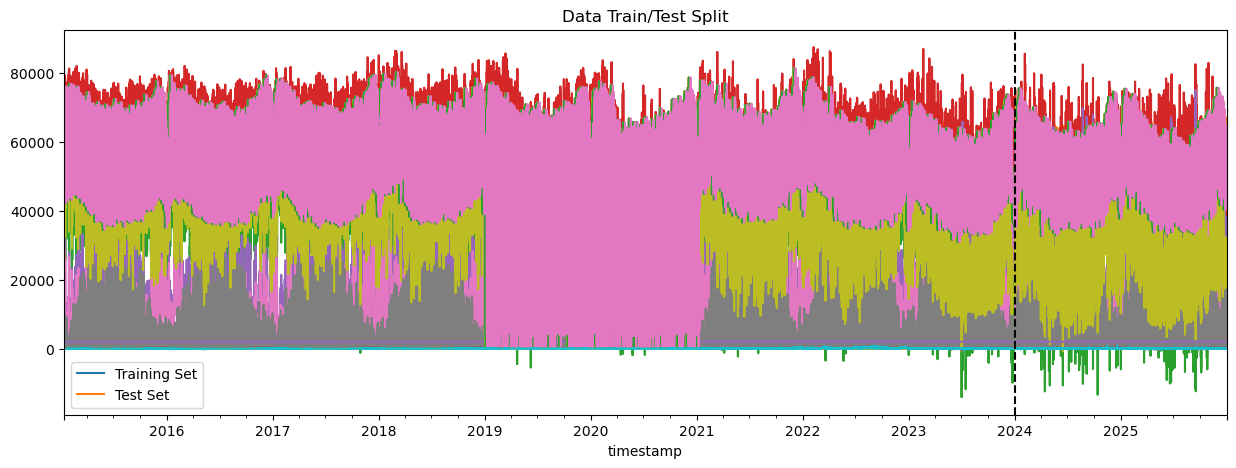

In [49]:
# Check and visualize Train and Test Data Split (Just for visualization and understanding)

split_date = "2024-01-01"
train = df_elec_price[df_elec_price.index < split_date]
test = df_elec_price[df_elec_price.index >= split_date]
fig, ax = plt.subplots(figsize=(15, 5))
train.plot(label="Training Set", title="Data Train/Test Split", ax=ax)
test.plot(label="Test Set", ax=ax)
ax.legend(["Training Set", "Test Set"])
ax.axvline(split_date, color="black", ls="--")
plt.show()

In [50]:
print(df_elec_price.index.dtype)

datetime64[ns]


In [51]:
print(df_elec_price.index.min())
print(df_elec_price.index.max())

2015-01-12 00:00:00
2025-12-31 23:00:00


In [52]:
print(train.shape)
print(test.shape)

(78624, 40)
(17544, 40)


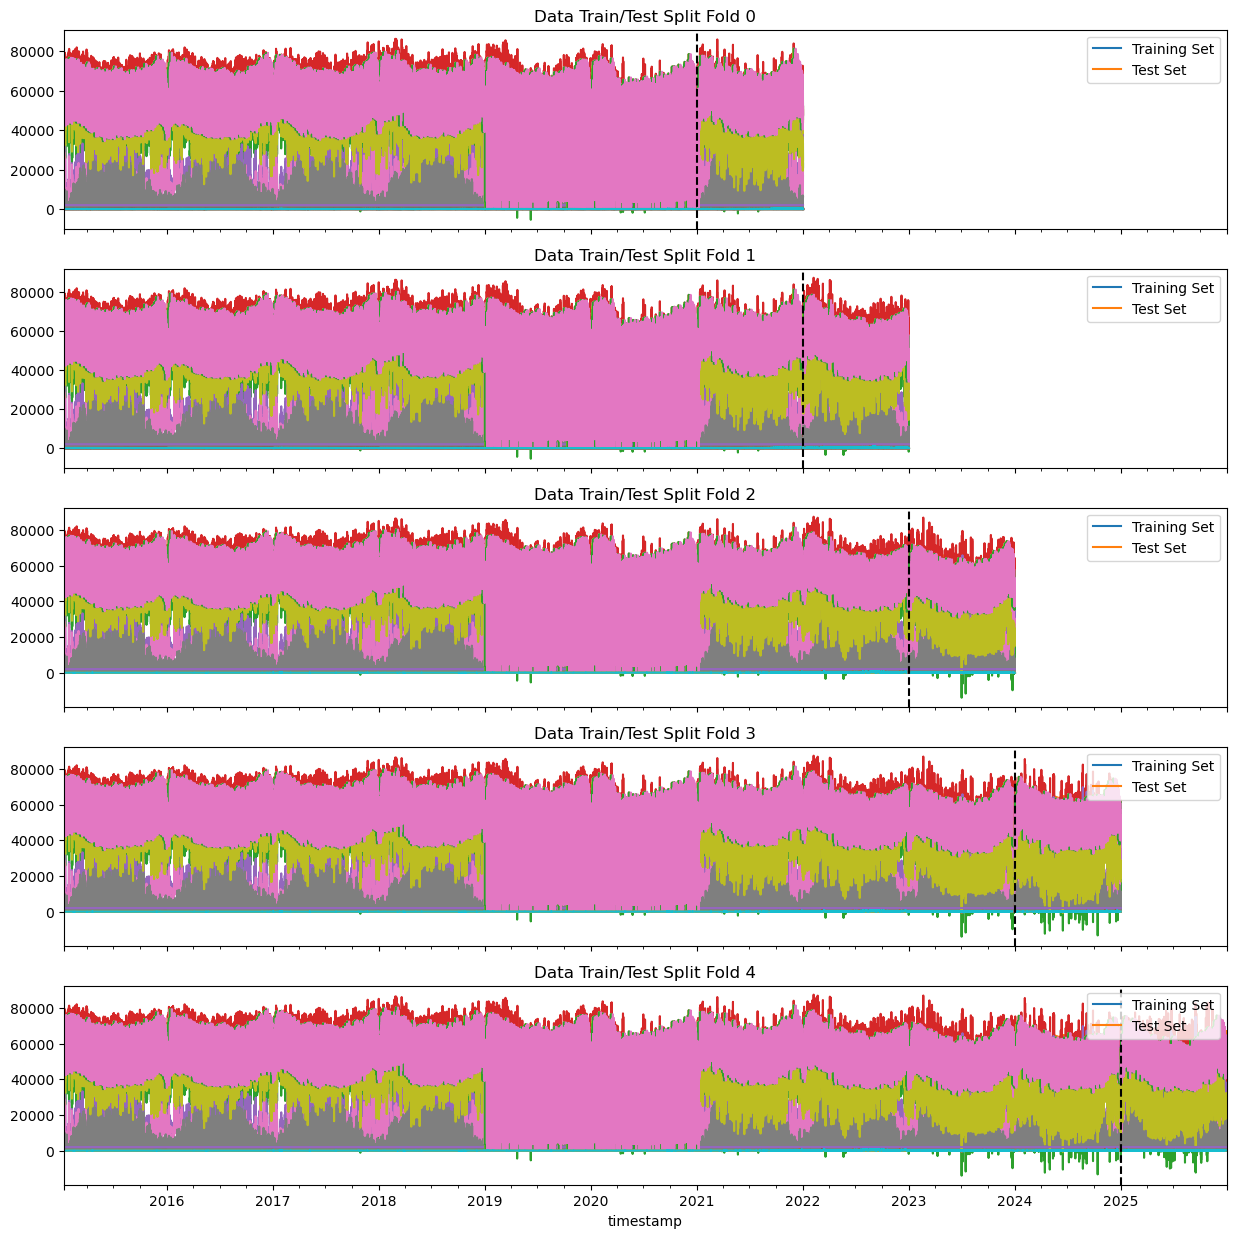

In [49]:
# Time Series Cross Validation Visualization 

tscv = TimeSeriesSplit(n_splits = 5, test_size = 24*365, gap = 24)
df_elec_price = df_elec_price.sort_index()



# Visualize Time Series Validation Split
fig, axs = plt.subplots(5, 1, figsize = (15, 15),
                             sharex =True)
fold = 0
for train_indx, val_indx in tscv.split(df_elec_price):
    train = df_elec_price.iloc[train_indx]
    test = df_elec_price.iloc[val_indx]
    train.plot(label="Training Set", 
               title=f"Data Train/Test Split Fold {fold}", 
               ax=axs[fold])
    test.plot(label="Test Set",
              ax=axs[fold])
    axs[fold].legend(["Training Set", "Test Set"], loc="upper right")
    axs[fold].axvline(test.index.min(), color="black", ls="--")
    fold += 1
plt.show()  

In [50]:
# Train Using Cross Validation

Target = "Germany/Luxembourg_EUR/MWh_Calculated_resolution"

Features = df_elec_price.columns.drop(Target)


for train_indx, val_indx in tscv.split(df_elec_price):
    train = df_elec_price.iloc[train_indx]
    test = df_elec_price.iloc[val_indx]


    X_train = train[Features]
    y_train = train[Target]
    X_test = test[Features]
    y_test = test[Target]


    model_xgb = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=6,
        random_state=42,
        n_jobs = 1,
        objective="reg:squarederror"
    )
    
    
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose = 100
    )
    
    
    
    model_lgbm = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=-1,       
        random_state=42,
        n_jobs = 1,
        objective="regression",
        verbose = -1
    )
    
    
    model_lgbm.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)]
    )

    
    # Make Predictions
    y_pred = model_xgb.predict(X_test)

    y_pred2 = model_lgbm.predict(X_test)
    
    # Model evaluation xgb
    xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    xgb_mae = mean_absolute_error(y_test, y_pred)
    xgb_r2 = r2_score(y_test, y_pred)

    # Model evaluation lgb
    lgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
    lgb_mae = mean_absolute_error(y_test, y_pred2)
    lgb_r2 = r2_score(y_test, y_pred2)

[0]	validation_0-rmse:16.40034	validation_1-rmse:96.11254
[100]	validation_0-rmse:7.22171	validation_1-rmse:73.81211
[200]	validation_0-rmse:4.33170	validation_1-rmse:66.92755
[300]	validation_0-rmse:3.45035	validation_1-rmse:65.02943
[400]	validation_0-rmse:3.11620	validation_1-rmse:64.45604
[500]	validation_0-rmse:2.93178	validation_1-rmse:64.18853
[600]	validation_0-rmse:2.80542	validation_1-rmse:64.04579
[700]	validation_0-rmse:2.71454	validation_1-rmse:63.99851
[800]	validation_0-rmse:2.64333	validation_1-rmse:63.93615
[900]	validation_0-rmse:2.58705	validation_1-rmse:63.91202
[999]	validation_0-rmse:2.53836	validation_1-rmse:63.89761
[0]	validation_0-rmse:38.22263	validation_1-rmse:237.19332
[100]	validation_0-rmse:15.37304	validation_1-rmse:126.32561
[200]	validation_0-rmse:7.62275	validation_1-rmse:94.45719
[300]	validation_0-rmse:5.22812	validation_1-rmse:84.73538
[400]	validation_0-rmse:4.44004	validation_1-rmse:81.52463
[500]	validation_0-rmse:4.07565	validation_1-rmse:79.43

In [51]:
# Model evaluation (XGBoost and LightGBM)

print("Model Y_Prediction:", y_pred)
print("Model Y_Prediction2:", y_pred2)

print("RMSE XGBoost:", xgb_rmse)
print("RMSE Lightgbm:", lgb_rmse)

print("MAE XGBoost:", xgb_mae)
print("MAE Lightgbm:", lgb_mae)

print("R2 XGBoost:", xgb_r2)
print("R2 Lightgbm:", lgb_r2)

Model Y_Prediction: [ 1.5113453  2.8363352  4.080853  ... 77.17452   72.26017   68.87316  ]
Model Y_Prediction2: [ 0.98734574  0.68158617  1.76014257 ... 78.23464882 72.58248311
 69.52054553]
RMSE XGBoost: 13.580924264935897
RMSE Lightgbm: 13.136895266341408
MAE XGBoost: 7.659696765646886
MAE Lightgbm: 7.672484664875499
R2 XGBoost: 0.9320409506550076
R2 Lightgbm: 0.9364121537612619


Both gradient boosting models performed competitively. 
LightGBM achieved slightly better generalization (lower RMSE and higher R2), and was selected as the final model.

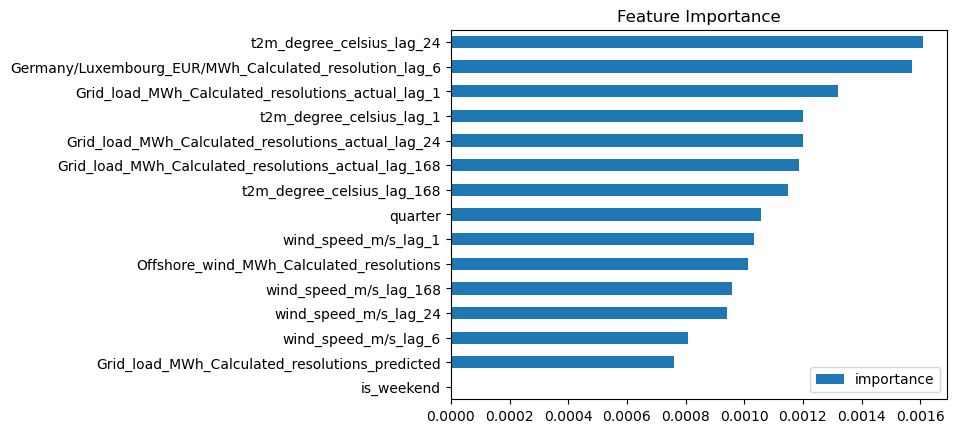

In [52]:
# Feature Importances

feature_import = pd.DataFrame(data=model_xgb.feature_importances_,
             index=model_xgb.feature_names_in_,
             columns=["importance"])

feature_import.sort_values("importance").head(15).plot(kind="barh", title="Feature Importance")
plt.show()

In [53]:
# Create a DataFrame df_predictions that has two columns: "Actual" and "Predicted"

df_predictions = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": y_pred2
    }
).round(2)

df_predictions

,Actual,Predicted
timestamp,,
2025-01-01 00:00:00,2.16,0.99
2025-01-01 01:00:00,1.60,0.68
2025-01-01 02:00:00,0.00,1.76
2025-01-01 03:00:00,-0.01,-0.59
2025-01-01 04:00:00,-0.01,0.29
...,...,...
2025-12-31 19:00:00,95.99,97.61
2025-12-31 20:00:00,86.80,88.03
2025-12-31 21:00:00,79.80,78.23


In [54]:
# Visualize a time series line plot for the values of predictions.

fig = px.line(df_predictions, labels={"value": "Germany/Luxembourg_EUR/MWh_Calculated_resolution"})
fig.show()

In [55]:
# Calculate Error
df_predictions["Error"] = df_predictions["Predicted"] - df_predictions["Actual"]
df_predictions

,Actual,Predicted,Error
timestamp,,,
2025-01-01 00:00:00,2.16,0.99,-1.17
2025-01-01 01:00:00,1.60,0.68,-0.92
2025-01-01 02:00:00,0.00,1.76,1.76
2025-01-01 03:00:00,-0.01,-0.59,-0.58
2025-01-01 04:00:00,-0.01,0.29,0.30
...,...,...,...
2025-12-31 19:00:00,95.99,97.61,1.62
2025-12-31 20:00:00,86.80,88.03,1.23
2025-12-31 21:00:00,79.80,78.23,-1.57


In [56]:
# Save Model with Joblib
joblib.dump(model_lgbm, "electricity_price_lgbm_model.joblib")

['electricity_price_lgbm_model.joblib']

In [57]:
# Calculate error
df_predictions["Error"] = df_predictions["Predicted"] - df_predictions["Actual"]

# Add timestamp column in desired format
df_predictions["Timestamp"] = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

# Save to CSV
df_predictions.reset_index().to_csv("actual_predictions_error.csv", index=False)